In [4]:
from matplotlib import pyplot as plt

plt.rcParams['axes.labelsize'] = 14  # размер подписей осей

import pandas as pd
import numpy as np

from scipy.optimize import curve_fit
from scipy.stats import chi2_contingency

In [5]:
def f (x, A, b):
    return A * x + b

def calc_sigma (z : np.ndarray):
    sigma = np.zeros(len(z))
    sigma[0] = np.abs(z[1] - z[0])

    for i in range (1, len(z) - 1):
        sigma[i] = (np.abs(z[i] - z[i + 1]) + np.abs(z[i-1] - z[i])) / 2

    sigma[-1] = np.abs(z[-1] - z[-2])
    return sigma / 7



Часть 1. Измерение уселение от тока

In [2]:
Amplification_Current = pd.read_csv('Amplification_Current.csv', comment='#')

In [19]:
Amplification_Current['Amplification'] = (Amplification_Current['dU_mV']) / 140
Amplification_Current['Amplification'].mean()

np.float64(1.0714285714285714)

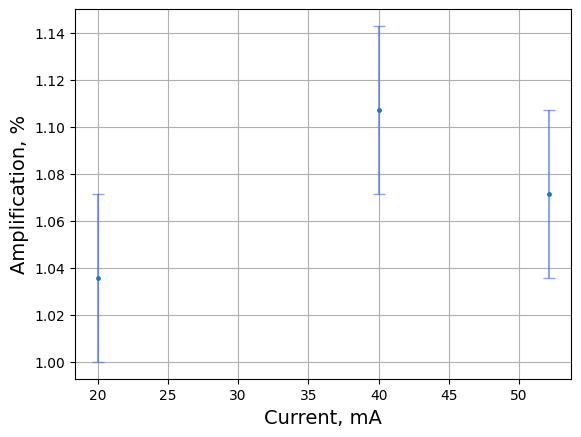

In [17]:
plt.errorbar(Amplification_Current['I_mA'], Amplification_Current['Amplification'], yerr = 5/140, linestyle = '', color = 'royalblue', alpha = 0.6, capsize = 4)
plt.scatter(Amplification_Current['I_mA'], Amplification_Current['Amplification'], s = 6, zorder = 10)

plt.grid()

plt.ylabel(r"Amplification, %")
plt.xlabel(r"Current, mA")


plt.show()

Часть 2. Зависимость напряжения от угла

In [ ]:
Intensity_Angle = pd.read_csv('Intensity_Angle.csv', comment='#')

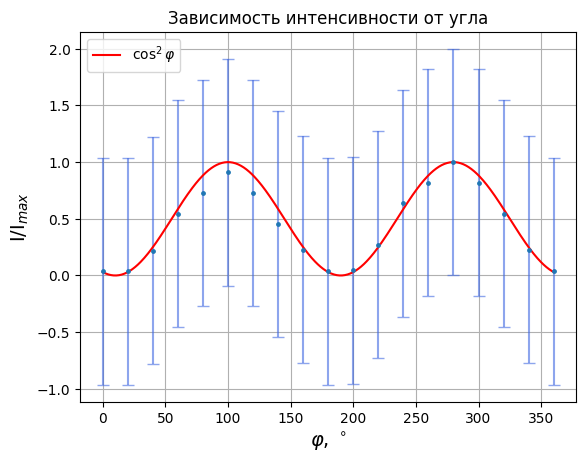

In [43]:
alpha = np.deg2rad(Intensity_Angle['alpha_deg'])

I_exp = Intensity_Angle['U_mV'] / np.max(Intensity_Angle['U_mV'])

# Подгонка угла максимума (можно взять просто максимум)
alpha0 = alpha[np.argmax(I_exp)]

alpha_fit = np.linspace(0, 2*np.pi, 500)
I_theory = np.cos(alpha_fit - alpha0)**2

plt.errorbar(Intensity_Angle['alpha_deg'], I_exp,
             yerr=1, linestyle='', color='royalblue',
             alpha=0.6, capsize=4)

plt.scatter(Intensity_Angle['alpha_deg'], I_exp, s=6, zorder=10)

plt.plot(np.rad2deg(alpha_fit), I_theory, color='red', label=r'$\cos^2\varphi$')

plt.xlabel(r'$\varphi$, $^\circ$')
plt.ylabel(r'$\text{I}/\text{I}_{max}$')
plt.title('Зависимость интенсивности от угла')
plt.legend()
plt.grid()
plt.show()

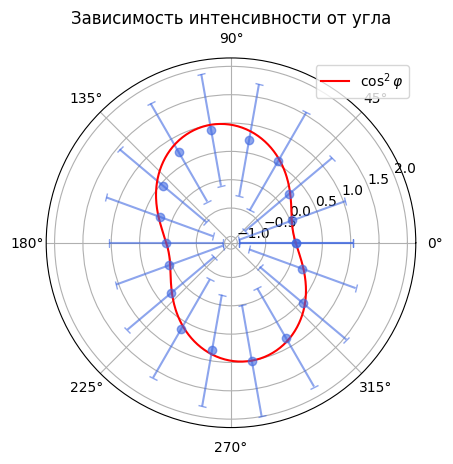

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')

# Эксперимент
ax.errorbar(alpha, I_exp,
            yerr=1, fmt='o',
            color='royalblue', alpha=0.6, capsize=3)

# Теория
ax.plot(alpha_fit, I_theory, color='red', label=r'$\cos^2\varphi$')

ax.set_title('Зависимость интенсивности от угла')
ax.legend()

plt.show()

Часть 3(дополнительная). Зависимость интенсивности от тока

In [47]:
Intensity_Current = pd.read_csv('Intensity_Current.csv', comment='#')
Intensity_Current

,I_mA,U_mV
0,21.0,10
1,25.0,18
2,26.0,25
3,30.0,35
4,34.0,45
5,38.0,50
6,44.0,57
7,48.0,57
8,52.1,60
9,46.0,51


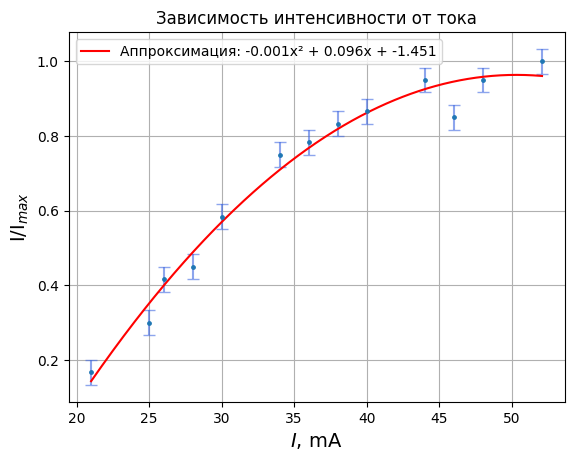

In [54]:
x = Intensity_Current['I_mA']
I_exp = Intensity_Current['U_mV'] / np.max(Intensity_Current['U_mV'])

coeffs = np.polyfit(x, I_exp, 2)   # [a, b, c]
poly = np.poly1d(coeffs)

x_fit = np.linspace(min(x), max(x), 500)
I_fit = poly(x_fit)

plt.errorbar(x, I_exp,
             yerr=2/60, linestyle='',
             color='royalblue', alpha=0.6, capsize=4)

plt.scatter(x, I_exp, s=6, zorder=10)

plt.plot(x_fit, I_fit, color='red',
         label=f'Аппроксимация: {coeffs[0]:.3f}x² + {coeffs[1]:.3f}x + {coeffs[2]:.3f}')

plt.xlabel(r'$I$, mA')
plt.ylabel(r'$\mathrm{I}/\mathrm{I}_{max}$')
plt.title('Зависимость интенсивности от тока')
plt.legend()
plt.grid()

plt.show()